# Лабораторная работа №3, вариант 8

### Цель работы: изучение принципов решения задачи классификации с использованием методов машинного обучения. 

Вариант 8 – Обнаружение нестабильной электрической сети 
Датасет – electrical_grid.csv 
Цель состоит в том, чтобы понимать и планировать как нарушения, так и колеба
ния производства и/или потребления энергии, вносимые участниками системы, дина
мическим образом, принимая во внимание не только технические аспекты, но и то, 
как участники реагируют на изменения в связанных с ними экономических аспектах 
(стоимость энергии). 
Набор данных содержит 10 000 наблюдений. Он также содержит 12 основных 
прогностических признаков и зависимую переменную. 
• Прогностические функции: 
tau1 – tau4: время реакции каждого участника сети, действительное значение в 
диапазоне от 0,5 до 10 (tau1 соответствует узлу-поставщику, tau2 – tau4 – узлам-по
требителям); 
p1 до'p4: номинальная мощность, произведенная (положительная) или потреб
ленная (отрицательная) каждым участником сети, реальное значение в диапазоне от 
2,0 до -0,5 для потребителей (p2 до p4). Поскольку общая потребляемая мощность 
равна общей генерируемой мощности, p1 (узел-поставщик) = - (p2 + p3 + p4); 
g1 – g4: коэффициент ценовой эластичности для каждого участника сети, дей
ствительное значение в диапазоне от 0,05 до 1,00 (g1 соответствует узлу-поставщику, 
g2 – g4 – узлам-потребителям; g означает гамма); 
• Зависимая переменная: 
stabf: категориальная (бинарная) метка («стабильный» или «нестабильный»). 

**1. Импортируйте необходимые библиотеки и загружаем данные**

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('electrical_grid.csv')
df.head()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,unstable


**Вывод целевой переменной, целевого имени и количества вхождений**

In [2]:
(unique, counts) = np.unique(df['stabf'], return_counts=True)
print('Уникальные значения целевой переменной: ', unique)
print('Количество каждого значения:', counts)

Уникальные значения целевой переменной:  ['stable' 'unstable']
Количество каждого значения: [3620 6380]


**Построим столбчатую диаграмму целевой переменной**

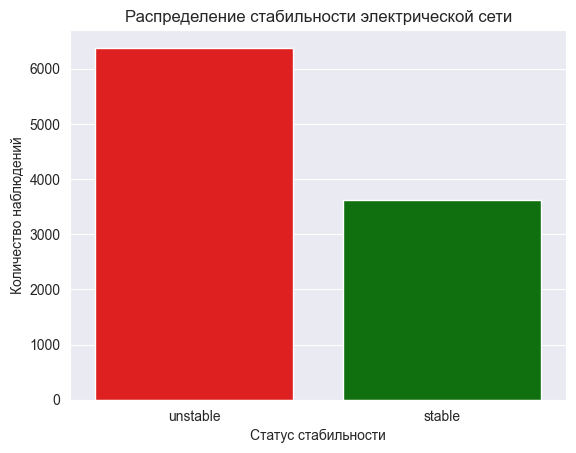

In [11]:
sns.countplot(data=df, x='stabf', hue='stabf', palette=['red', 'green'])
plt.title('Распределение стабильности электрической сети')
plt.xlabel('Статус стабильности')
plt.ylabel('Количество наблюдений')
plt.show()

Набор данных умеренно сбалансирован. На диаграмме видно, что класс “unstable” встречается чаще (около 64 %) по сравнению с классом “stable” (около 36 %). Несмотря на небольшое преобладание одного класса, дисбаланс не является критическим, поэтому набор данных можно считать условно сбалансированным.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tau1    10000 non-null  float64
 1   tau2    10000 non-null  float64
 2   tau3    10000 non-null  float64
 3   tau4    10000 non-null  float64
 4   p1      10000 non-null  float64
 5   p2      10000 non-null  float64
 6   p3      10000 non-null  float64
 7   p4      10000 non-null  float64
 8   g1      10000 non-null  float64
 9   g2      10000 non-null  float64
 10  g3      10000 non-null  float64
 11  g4      10000 non-null  float64
 12  stabf   10000 non-null  object 
dtypes: float64(12), object(1)
memory usage: 1015.8+ KB


В этом наборе данных у нас есть два класса: "stable" и "unstable", приравниваем их к бинарным значениям 0 и 1, что делает эту задачу задачей бинарной классификации

**2. Проверяем наличие пропущенных значений и выбросов**

In [8]:
print(df.isnull().sum())

tau1     0
tau2     0
tau3     0
tau4     0
p1       0
p2       0
p3       0
p4       0
g1       0
g2       0
g3       0
g4       0
stabf    0
dtype: int64


Ящик с усами для времени реакции узла-поставщика (tau1)
Отображает основные статистические характеристики распределения: медиану, квартили и выбросы. Выбросы, отображаемые точками, не наблюдаются.

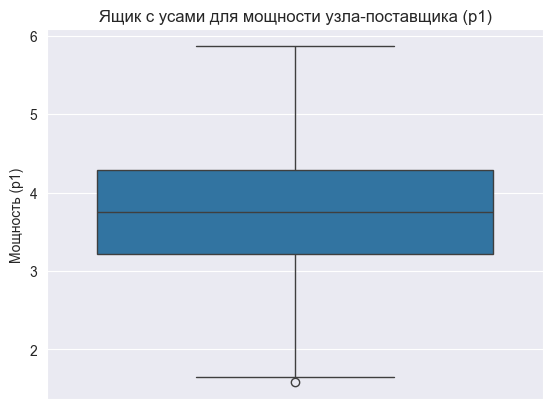

In [13]:
sns.boxplot(data=df, y='p1')
plt.title('Ящик с усами для мощности узла-поставщика (p1)')
plt.ylabel('Мощность (p1)')
plt.show()

p1 (Номинальная мощность узла-поставщика) расчетная величина, следовательно скачки измерений в p2-p4 складываются и создают выбросы в p1

**3. Исключаем невлияющие категориальные признаки**

В нашем случае нет необходимости удалять категориальные признаки, так как все признаки, кроме целевой переменной stapf являются количественными.

In [18]:
df_copy = df.copy()
binary_stabf = {'stable': 0, 'unstable': 1}
df_copy['stabf'] = df_copy['stabf'].map(binary_stabf)
df_copy.head()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,1
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,0
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,1
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,1
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,1


В нашем случае пропущенные значения и другие категориальные признаки отсутствуют, поэтому закончим преобразование.

In [21]:
print(df_copy.isnull().sum())

tau1     0
tau2     0
tau3     0
tau4     0
p1       0
p2       0
p3       0
p4       0
g1       0
g2       0
g3       0
g4       0
stabf    0
dtype: int64


**4. Разделяем данные на признаки и целевую перемнную**

In [25]:
y = df_copy['stabf']
X = df_copy.drop('stabf', axis=1)

print("Целевая переменная (y):")
print(y.head())

print("\nПризнаки (X):")
print(X.head())

Целевая переменная (y):
0    1
1    0
2    1
3    1
4    1
Name: stabf, dtype: int64

Признаки (X):
       tau1      tau2      tau3      tau4        p1        p2        p3  \
0  2.959060  3.079885  8.381025  9.780754  3.763085 -0.782604 -1.257395   
1  9.304097  4.902524  3.047541  1.369357  5.067812 -1.940058 -1.872742   
2  8.971707  8.848428  3.046479  1.214518  3.405158 -1.207456 -1.277210   
3  0.716415  7.669600  4.486641  2.340563  3.963791 -1.027473 -1.938944   
4  3.134112  7.608772  4.943759  9.857573  3.525811 -1.125531 -1.845975   

         p4        g1        g2        g3        g4  
0 -1.723086  0.650456  0.859578  0.887445  0.958034  
1 -1.255012  0.413441  0.862414  0.562139  0.781760  
2 -0.920492  0.163041  0.766689  0.839444  0.109853  
3 -0.997374  0.446209  0.976744  0.929381  0.362718  
4 -0.554305  0.797110  0.455450  0.656947  0.820923  


**5. Применяем операцию нормализации для численной устойчивости**

In [26]:
from sklearn.preprocessing import StandardScaler
standardizer = StandardScaler()
X = standardizer.fit_transform(X)

print("Данные после нормализации:")
print(X)
print(f"Размер: {X.shape}")

Данные после нормализации:
[[-0.83537431 -0.79131661  1.14170354 ...  1.22001311  1.32162751
   1.57902607]
 [ 1.47829663 -0.12670487 -0.80311147 ...  1.23035426  0.13542358
   0.93625569]
 [ 1.35709296  1.31213982 -0.80349871 ...  0.88129868  1.14659573
  -1.51380226]
 ...
 [-1.05234609 -0.87804866  1.28587062 ...  1.68284371 -1.37001304
  -1.38205402]
 [ 1.59768553 -0.45784646 -0.90902909 ...  0.22811049  1.32772953
   1.06982944]
 [ 0.4669346   0.55855544 -0.32829064 ... -0.0713212  -0.53325125
   1.52285961]]
Размер: (10000, 12)


**6. Разделяем данные на тренировочный и тестовый наборы**

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y , test_size=0.25, random_state=0)

**7. Обучаем модель логической регрессии**

In [29]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [30]:
y_pred = model.predict(X_test)

**8. Рассчитываем показатели точности, сравнив фактические и прогнозируемые значения**

In [31]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = confusion_matrix(y_test, y_pred).ravel()

print('True Positive(TP) = ', TP)
print('False Positive(FP) = ', FP)
print('True Negative(TN) = ', TN)
print('False Negative(FN) = ', FN)

accuracy = (TP+TN) /(TP+FP+TN+FN)
print('Accuracy of the binary classification = {:0.3f}'.format(accuracy))

True Positive(TP) =  1377
False Positive(FP) =  270
True Negative(TN) =  661
False Negative(FN) =  192
Accuracy of the binary classification = 0.815


In [32]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print('Accuracy:', accuracy)

Accuracy: 0.8152


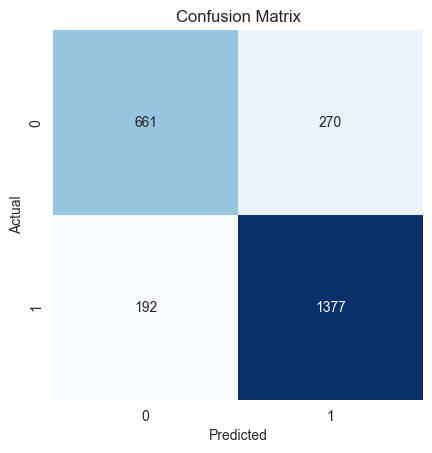

In [33]:
sns.heatmap(cm, square=True, annot=True, fmt='d', cbar=False, cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [34]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Точность: {accuracy:.2f}")

Точность: 0.82


In [36]:
from sklearn.metrics import precision_score, recall_score
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
print(f"Точность: {precision:.2f}")
print(f"Полнота: {recall:.2f}")

Точность: 0.84
Полнота: 0.88


In [37]:
# Оценка F1-меры
from sklearn.metrics import f1_score
f1 = f1_score(y_test, y_pred)
print(f"F1-мера: {f1:.2f}")

F1-мера: 0.86


In [38]:
df_copy.corr()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stabf
tau1,1.000000,0.015586,-0.005970,-0.017265,0.027183,-0.015485,-0.015924,-0.015807,0.010521,0.015350,-0.001279,0.005494,0.234898
tau2,0.015586,1.000000,0.014273,-0.001965,-0.004769,0.006573,0.007673,-0.005963,-0.001742,0.015383,0.016508,-0.011764,0.246280
tau3,-0.005970,0.014273,1.000000,0.004354,0.016953,-0.003134,-0.008780,-0.017531,-0.011605,0.007671,0.014702,-0.011497,0.237492
tau4,-0.017265,-0.001965,0.004354,1.000000,-0.003173,0.010553,0.006169,-0.011211,-0.004149,0.008431,0.003260,-0.000491,0.239375
p1,0.027183,-0.004769,0.016953,-0.003173,1.000000,-0.573157,-0.584554,-0.579239,0.000721,0.015405,0.001069,-0.015451,0.009938
p2,-0.015485,0.006573,-0.003134,0.010553,-0.573157,1.000000,0.002388,-0.006844,0.015603,-0.018032,0.007555,0.019817,0.006173
p3,-0.015924,0.007673,-0.008780,0.006169,-0.584554,0.002388,1.000000,0.012953,-0.003219,-0.011575,-0.005897,-0.010485,-0.000649
p4,-0.015807,-0.005963,-0.017531,-0.011211,-0.579239,-0.006844,0.012953,1.000000,-0.013636,0.002850,-0.003515,0.017505,-0.022785
g1,0.010521,-0.001742,-0.011605,-0.004149,0.000721,0.015603,-0.003219,-0.013636,1.000000,0.007559,-0.005836,0.012431,0.197664
g2,0.015350,0.015383,0.007671,0.008431,0.015405,-0.018032,-0.011575,0.002850,0.007559,1.000000,-0.012809,-0.014909,0.217341


Модель правильно предсказывает в 82% случаев. Для класса "Stable" (0): правильно предсказано 661 случаев; ошибочно предсказано как Unstable 270 случаев; точность для Stable = 0.71.
Для класса "Unstable" (1): правильно предсказано: 1377 случаев; ошибочно предсказано как Stable: 192 случаев; точность для Unstable = 0.88.

**9. Строим ROC-кривую**

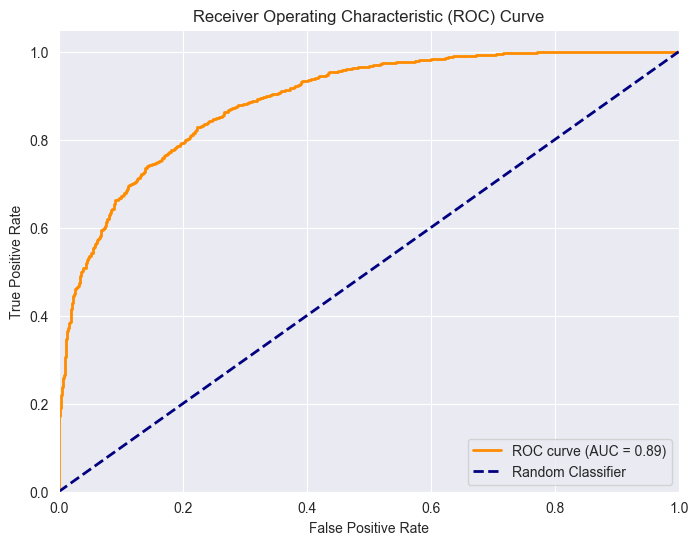

In [40]:
from sklearn.metrics import roc_curve, auc

# Получаем предсказанные вероятности для класса 1 (unstable)
y_score = model.predict_proba(X_test)[:, 1]

# Рассчитываем FPR, TPR и пороги
fpr, tpr, thresholds = roc_curve(y_test, y_score)

# Рассчитываем AUC (Area Under Curve) - площадь под кривой
roc_auc = auc(fpr, tpr)

# Строим график
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

Исходный набор данных характеризуется умеренной несбалансированностью. Несмотря на преобладание класса "unstable", модель логистической регрессии демонстрирует высокую эффективность (AUC 0.89), что свидетельствует о способности алгоритма успешно обучаться на данных с таким распределением.